# **Pengolahan Data Shopping Trends untuk Aplikasi Rekomendasi Produk Berdasarkan Pola Pembelian Pelanggan (DSS)**

# **1. Import library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# **2. Upload dataset CSV**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving shopping_trends_updated.csv to shopping_trends_updated.csv


# **3. Extract Data**

## 3.1 Upload Dataset

In [ ]:
df = pd.read_csv('shopping_trends_updated.csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


## 3.2 Membaca Dataset CSV

In [ ]:
file_name = list(uploaded.keys())[0]
df_raw = pd.read_csv(file_name)

## 3.3 Menampilkan Data Awal

In [ ]:
df_raw.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


# **4. Data understanding**



## 4.1 Mengecek Jumlah Baris dan Kolom




In [ ]:
df_raw.shape

(3900, 18)

## 4.2 Mengecek Informasi Dataset



In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

## 4.3 Mengecek Nama Kolom





In [ ]:
df_raw.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

## 4.4 Menampilkan Contoh Data

In [ ]:
df_raw.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


## 4.5 Mengecek Statistik Deskriptif

In [ ]:
df_raw.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


# **5. Transform Data**


## 5.1 Membuat Salinan Dataset

In [ ]:
df_transform = df_raw.copy()



> Penjelasan:
Tahap Transform dilakukan pada data salinan agar data asli tetap aman.



## 5.2 Merapikan Nama Kolom

In [ ]:
df_transform.columns = df_transform.columns.str.lower()
df_transform.columns = df_transform.columns.str.replace(' ', '_')
df_transform.columns = df_transform.columns.str.replace('-', '_')

df_transform.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_(usd)', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')



> Tujuan:
Agar nama kolom lebih rapi dan mudah digunakan.

> Contoh:
Customer ID menjadi customer_id.







# **5.3 Mengecek Missing Value**

In [ ]:
df_transform.isnull().sum()

,0
customer_id,0
age,0
gender,0
item_purchased,0
category,0
purchase_amount_(usd),0
location,0
size,0
color,0
season,0


## 5.4 Mengecek Data Duplikat

In [ ]:
df_transform.duplicated().sum()

np.int64(0)

## 5.7 Mengecek Tipe Data Setelah Cleaning

In [ ]:
df_transform.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             3900 non-null   int64  
 1   age                     3900 non-null   int64  
 2   gender                  3900 non-null   object 
 3   item_purchased          3900 non-null   object 
 4   category                3900 non-null   object 
 5   purchase_amount_(usd)   3900 non-null   int64  
 6   location                3900 non-null   object 
 7   size                    3900 non-null   object 
 8   color                   3900 non-null   object 
 9   season                  3900 non-null   object 
 10  review_rating           3900 non-null   float64
 11  subscription_status     3900 non-null   object 
 12  shipping_type           3900 non-null   object 
 13  discount_applied        3900 non-null   object 
 14  promo_code_used         3900 non-null   

# **6. Feature Engineering**

## 6.1 Menentukan Kolom Nilai Transaksi

In [ ]:
df_transform.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_(usd)', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [ ]:
amount_col = 'purchase_amount_(usd)'

## 6.2 Membuat Age Group

In [ ]:
def create_age_group(age):
    if age < 25:
        return 'Young Adult'
    elif age < 40:
        return 'Adult'
    elif age < 55:
        return 'Middle Age'
    else:
        return 'Senior'

df_transform['age_group'] = df_transform['age'].apply(create_age_group)
df_transform[['age', 'age_group']].head()

,age,age_group
0,55,Senior
1,19,Young Adult
2,50,Middle Age
3,21,Young Adult
4,45,Middle Age




> Fungsi:
Mengelompokkan umur pelanggan agar lebih mudah dianalisis.



## 6.3 Membuat Revenue Segment

In [ ]:
def create_revenue_segment(amount):
    if amount < 40:
        return 'Low Revenue'
    elif amount < 75:
        return 'Medium Revenue'
    else:
        return 'High Revenue'

df_transform['revenue_segment'] = df_transform[amount_col].apply(create_revenue_segment)
df_transform[[amount_col, 'revenue_segment']].head()

,purchase_amount_(usd),revenue_segment
0,53,Medium Revenue
1,64,Medium Revenue
2,73,Medium Revenue
3,90,High Revenue
4,49,Medium Revenue




> Fungsi:
Mengelompokkan nilai transaksi pelanggan menjadi Low, Medium, dan High Revenue.



## 6.4 Mengecek Frekuensi Pembelian

In [ ]:
df_transform['frequency_of_purchases'].unique()

array(['Fortnightly', 'Weekly', 'Annually', 'Quarterly', 'Bi-Weekly',
       'Monthly', 'Every 3 Months'], dtype=object)



> Fungsi:
Melihat kategori frekuensi pembelian yang ada di dataset.



## 6.5 Membuat Frequency Score

In [ ]:
frequency_mapping = {
    'Weekly': 5,
    'Fortnightly': 4,
    'Bi-Weekly': 4,
    'Monthly': 3,
    'Every 3 Months': 2,
    'Quarterly': 2,
    'Annually': 1
}

df_transform['frequency_score'] = df_transform['frequency_of_purchases'].map(frequency_mapping)
df_transform[['frequency_of_purchases', 'frequency_score']].head()

,frequency_of_purchases,frequency_score
0,Fortnightly,4
1,Fortnightly,4
2,Weekly,5
3,Weekly,5
4,Annually,1




> Fungsi:
Mengubah frekuensi pembelian menjadi skor numerik.



## 6.6 Mengecek Frequency Score Kosong

In [ ]:
df_transform['frequency_score'].isnull().sum()

np.int64(0)

## 6.7 Membuat Customer Segment

In [ ]:
def create_revenue_segment(amount):
    if amount < 40:
        return 'Low Revenue'
    elif amount < 75:
        return 'Medium Revenue'
    else:
        return 'High Revenue'

frequency_mapping = {
    'Weekly': 5,
    'Fortnightly': 4,
    'Bi-Weekly': 4,
    'Monthly': 3,
    'Every 3 Months': 2,
    'Quarterly': 2,
    'Annually': 1
}

df_transform['revenue_segment'] = df_transform[amount_col].apply(create_revenue_segment)
df_transform['frequency_score'] = df_transform['frequency_of_purchases'].map(frequency_mapping)

def create_customer_segment(row):
    if row['revenue_segment'] == 'High Revenue' and row['frequency_score'] >= 4:
        return 'Loyal Customer'
    elif row['revenue_segment'] == 'High Revenue':
        return 'High Value Customer'
    elif row['revenue_segment'] == 'Medium Revenue' and row['frequency_score'] >= 3:
        return 'Potential Customer'
    else:
        return 'Regular Customer'

df_transform['customer_segment'] = df_transform.apply(create_customer_segment, axis=1)
df_transform[['revenue_segment', 'frequency_score', 'customer_segment']].head()

,revenue_segment,frequency_score,customer_segment
0,Medium Revenue,4,Potential Customer
1,Medium Revenue,4,Potential Customer
2,Medium Revenue,5,Potential Customer
3,High Revenue,5,Loyal Customer
4,Medium Revenue,1,Regular Customer




> Fungsi:
Membagi pelanggan menjadi beberapa segmen berdasarkan nilai transaksi dan frekuensi pembelian.



## 6.8 Membuat Recommendation Category



In [ ]:
def create_recommendation_category(row):
    if row['category'] == 'Clothing' and row['season'] == 'Winter':
        return 'Winter Clothing Recommendation'
    elif row['category'] == 'Clothing':
        return 'Clothing Recommendation'
    elif row['category'] == 'Accessories':
        return 'Accessories Recommendation'
    elif row['category'] == 'Footwear':
        return 'Footwear Recommendation'
    elif row['category'] == 'Outerwear':
        return 'Outerwear Recommendation'
    else:
        return 'Similar Product Category Recommendation'

df_transform['recommendation_category'] = df_transform.apply(create_recommendation_category, axis=1)
df_transform[['category', 'season', 'recommendation_category']].head()

,category,season,recommendation_category
0,Clothing,Winter,Winter Clothing Recommendation
1,Clothing,Winter,Winter Clothing Recommendation
2,Clothing,Spring,Clothing Recommendation
3,Footwear,Spring,Footwear Recommendation
4,Clothing,Spring,Clothing Recommendation




> Fungsi:
Memberikan kategori rekomendasi berdasarkan kategori produk dan musim pembelian.



## 6.9 Membuat Recommendation Score

In [ ]:
def create_recommendation_score(row):
    score = 50

    if row['frequency_score'] >= 4:
        score += 20

    if row['review_rating'] >= 4:
        score += 15

    if row['revenue_segment'] == 'High Revenue':
        score += 15

    return min(score, 100)

df_transform['recommendation_score'] = df_transform.apply(create_recommendation_score, axis=1)
df_transform[['frequency_score', 'review_rating', 'revenue_segment', 'recommendation_score']].head()

,frequency_score,review_rating,revenue_segment,recommendation_score
0,4,3.1,Medium Revenue,70
1,4,3.1,Medium Revenue,70
2,5,3.1,Medium Revenue,70
3,5,3.5,High Revenue,85
4,1,2.7,Medium Revenue,50




> Fungsi:
Memberikan skor rekomendasi produk berdasarkan frekuensi pembelian, rating, dan segmen revenue.



# **7. Load Data**


## 7.1 Membuat Tabel Analitik Tunggal

In [ ]:
customer_purchase_analysis = df_transform.copy()
customer_purchase_analysis.head()

,customer_id,age,gender,item_purchased,category,purchase_amount_(usd),location,size,color,season,...,promo_code_used,previous_purchases,payment_method,frequency_of_purchases,age_group,revenue_segment,frequency_score,customer_segment,recommendation_category,recommendation_score
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Yes,14,Venmo,Fortnightly,Senior,Medium Revenue,4,Potential Customer,Winter Clothing Recommendation,70
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Yes,2,Cash,Fortnightly,Young Adult,Medium Revenue,4,Potential Customer,Winter Clothing Recommendation,70
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Yes,23,Credit Card,Weekly,Middle Age,Medium Revenue,5,Potential Customer,Clothing Recommendation,70
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,Yes,49,PayPal,Weekly,Young Adult,High Revenue,5,Loyal Customer,Footwear Recommendation,85
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,Yes,31,PayPal,Annually,Middle Age,Medium Revenue,1,Regular Customer,Clothing Recommendation,50




> Penjelasan:
Tahap Load dilakukan dengan menyimpan data hasil transformasi ke dalam satu tabel analitik bernama customer_purchase_analysis.



## 7.2 Mengecek Struktur Tabel Akhir

In [ ]:
customer_purchase_analysis.shape

(3900, 24)

In [ ]:
customer_purchase_analysis.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_(usd)', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases', 'age_group',
       'revenue_segment', 'frequency_score', 'customer_segment',
       'recommendation_category', 'recommendation_score'],
      dtype='object')

In [ ]:
customer_purchase_analysis.head()

,customer_id,age,gender,item_purchased,category,purchase_amount_(usd),location,size,color,season,...,promo_code_used,previous_purchases,payment_method,frequency_of_purchases,age_group,revenue_segment,frequency_score,customer_segment,recommendation_category,recommendation_score
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Yes,14,Venmo,Fortnightly,Senior,Medium Revenue,4,Potential Customer,Winter Clothing Recommendation,70
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Yes,2,Cash,Fortnightly,Young Adult,Medium Revenue,4,Potential Customer,Winter Clothing Recommendation,70
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Yes,23,Credit Card,Weekly,Middle Age,Medium Revenue,5,Potential Customer,Clothing Recommendation,70
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,Yes,49,PayPal,Weekly,Young Adult,High Revenue,5,Loyal Customer,Footwear Recommendation,85
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,Yes,31,PayPal,Annually,Middle Age,Medium Revenue,1,Regular Customer,Clothing Recommendation,50


## 7.3 Menyimpan Hasil ETL ke CSV

In [ ]:
customer_purchase_analysis.to_csv('customer_purchase_analysis.csv', index=False)

## 7.4 Mengunduh Hasil ETL

In [ ]:
files.download('customer_purchase_analysis.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


# **8. Single Table Analytical Schema**

### 8.1 Penjelasan Skema yang Digunakan
Pada proyek ini, skema yang digunakan adalah Single Table Analytical Schema. Skema ini merupakan pendekatan pengolahan data yang menyimpan seluruh hasil preprocessing, transformasi, dan feature engineering ke dalam satu tabel analitik utama. Pendekatan ini dipilih karena dataset yang digunakan hanya berasal dari satu sumber data, yaitu file CSV Shopping Trends, sehingga tidak diperlukan pemisahan data ke dalam beberapa tabel dimensi dan tabel fakta seperti pada star schema.

Tabel utama yang dihasilkan dari proses ETL diberi nama customer_purchase_analysis. Tabel ini berisi data transaksi pelanggan yang telah dibersihkan dan dilengkapi dengan beberapa kolom tambahan hasil transformasi, seperti age_group, revenue_segment, frequency_score, customer_segment, recommendation_category, dan recommendation_score. Kolom-kolom tersebut digunakan untuk mendukung analisis Business Intelligence, segmentasi pelanggan, serta sistem rekomendasi produk berbasis Decision Support System.

8.2 Fungsi Tabel customer_purchase_analysis

Tabel customer_purchase_analysis berfungsi sebagai tabel analitik utama yang menyimpan seluruh data hasil proses ETL. Tabel ini berasal dari dataset Shopping Trends yang telah melalui tahap pembersihan data, perapian nama kolom, pengecekan missing value, pengecekan data duplikat, serta penambahan kolom baru melalui proses feature engineering.

Tabel ini digunakan sebagai sumber utama untuk dashboard Business Intelligence pada website. Melalui tabel customer_purchase_analysis, sistem dapat menampilkan berbagai informasi penting seperti total pelanggan, total transaksi, total revenue, rata-rata rating, kategori produk terlaris, musim pembelian paling aktif, metode pembayaran yang paling sering digunakan, serta pola pembelian pelanggan berdasarkan gender, kategori, dan season.

Selain digunakan untuk dashboard, tabel customer_purchase_analysis juga mendukung fungsi Decision Support System. Kolom tambahan seperti age_group, revenue_segment, frequency_score, customer_segment, recommendation_category, dan recommendation_score digunakan untuk membantu sistem dalam melakukan segmentasi pelanggan dan memberikan rekomendasi produk. Dengan demikian, tabel ini menjadi dasar utama dalam proses analisis data, visualisasi informasi, dan pengambilan keputusan berbasis data pada proyek ini.

# **9. BI Summary**

In [ ]:
total_customers = customer_purchase_analysis['customer_id'].nunique()
total_transactions = len(customer_purchase_analysis)
total_revenue = customer_purchase_analysis[amount_col].sum()
average_rating = customer_purchase_analysis['review_rating'].mean()
top_category = customer_purchase_analysis['category'].value_counts().idxmax()
top_season = customer_purchase_analysis['season'].value_counts().idxmax()
top_payment_method = customer_purchase_analysis['payment_method'].value_counts().idxmax()

summary_bi = pd.DataFrame({
    'metric': [
        'Total Customers',
        'Total Transactions',
        'Total Revenue',
        'Average Rating',
        'Top Category',
        'Top Season',
        'Top Payment Method'
    ],
    'value': [
        total_customers,
        total_transactions,
        total_revenue,
        round(average_rating, 2),
        top_category,
        top_season,
        top_payment_method
    ]
})

summary_bi

,metric,value
0,Total Customers,3900
1,Total Transactions,3900
2,Total Revenue,233081
3,Average Rating,3.75
4,Top Category,Clothing
5,Top Season,Spring
6,Top Payment Method,PayPal


# **10. Data Analysis**

### 10.1 Analisis kategori produk

In [ ]:
category_analysis = customer_purchase_analysis['category'].value_counts()
category_analysis

,count
category,
Clothing,1737
Accessories,1240
Footwear,599
Outerwear,324


### 10.2 Analisis revenue berdasarkan kategori

In [ ]:
revenue_by_category = customer_purchase_analysis.groupby('category')[amount_col].sum().sort_values(ascending=False)
revenue_by_category

,purchase_amount_(usd)
category,
Clothing,104264
Accessories,74200
Footwear,36093
Outerwear,18524


### 10.3 Analisis pembelian berdasarkan gender

In [ ]:
gender_analysis = customer_purchase_analysis['gender'].value_counts()
gender_analysis

,count
gender,
Male,2652
Female,1248


### 10.4 Analisis pembelian berdasarkan season

In [ ]:
season_analysis = customer_purchase_analysis['season'].value_counts()
season_analysis

,count
season,
Spring,999
Fall,975
Winter,971
Summer,955


### 10.5 Analisis metode pembayaran

In [ ]:
payment_analysis = customer_purchase_analysis['payment_method'].value_counts()
payment_analysis

,count
payment_method,
PayPal,677
Credit Card,671
Cash,670
Debit Card,636
Venmo,634
Bank Transfer,612


### 10.6 Analisis segmentasi pelanggan

In [ ]:
customer_segment_analysis = customer_purchase_analysis['customer_segment'].value_counts()
customer_segment_analysis

,count
customer_segment,
Regular Customer,1708
Potential Customer,938
High Value Customer,742
Loyal Customer,512


### 10.7 Analisis rekomendasi produk

In [ ]:
recommendation_analysis = customer_purchase_analysis['recommendation_category'].value_counts()
recommendation_analysis

,count
recommendation_category,
Clothing Recommendation,1289
Accessories Recommendation,1240
Footwear Recommendation,599
Winter Clothing Recommendation,448
Outerwear Recommendation,324


# **11. Data Visualization**


## 11.1 Visualisasi Kategori Produk

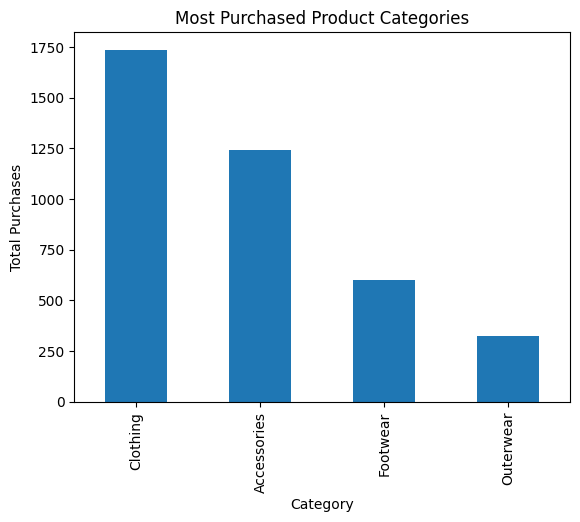

In [ ]:
category_analysis.plot(kind='bar')
plt.title('Most Purchased Product Categories')
plt.xlabel('Category')
plt.ylabel('Total Purchases')
plt.show()

## 11.2 Visualisasi Revenue Berdasarkan Kategori

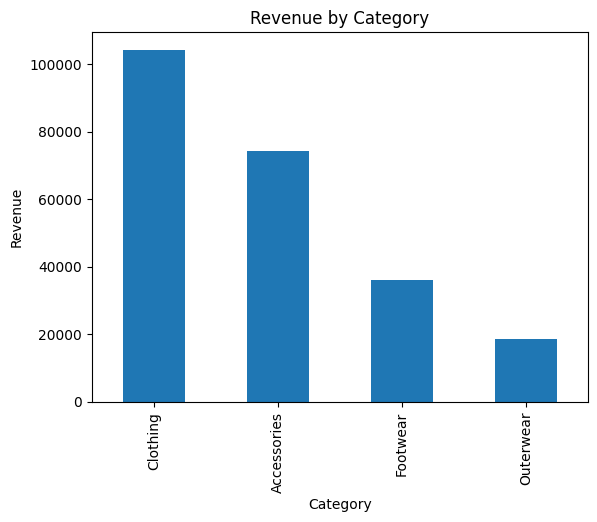

In [ ]:
revenue_by_category.plot(kind='bar')
plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.show()

## 11.3 Visualisasi Pembelian Berdasarkan Season

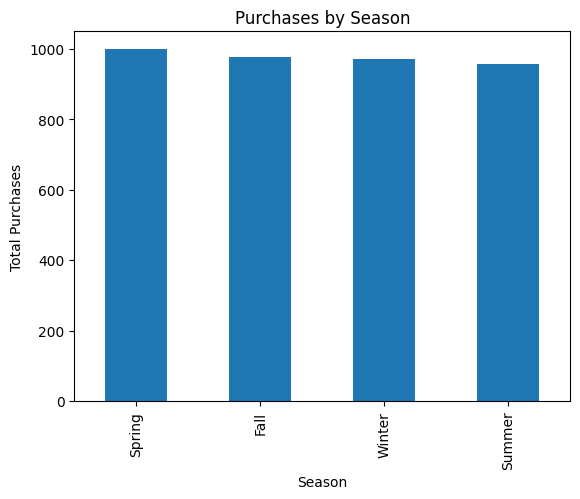

In [ ]:
season_analysis.plot(kind='bar')
plt.title('Purchases by Season')
plt.xlabel('Season')
plt.ylabel('Total Purchases')
plt.show()

## 11.4 Visualisasi Customer Segment

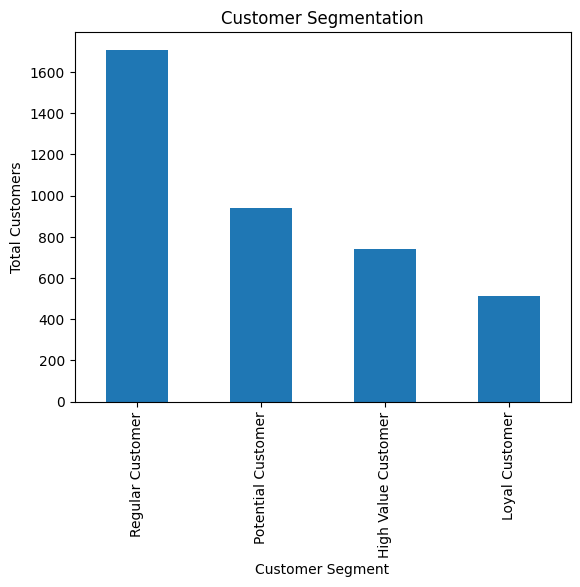

In [ ]:
customer_segment_analysis.plot(kind='bar')
plt.title('Customer Segmentation')
plt.xlabel('Customer Segment')
plt.ylabel('Total Customers')
plt.show()

## 11.5 Visualisasi Recommendation Category

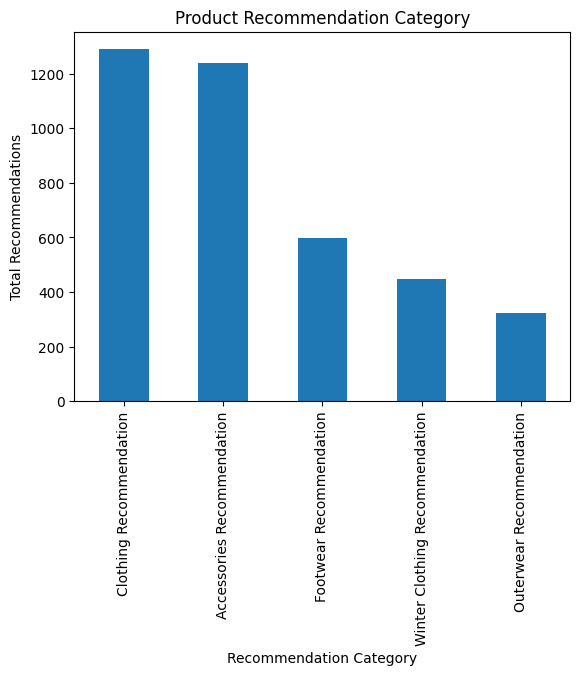

In [ ]:
recommendation_analysis.plot(kind='bar')
plt.title('Product Recommendation Category')
plt.xlabel('Recommendation Category')
plt.ylabel('Total Recommendations')
plt.show()

# **12. Insight Otomatis dan Preview Hasil Akhir**

## 12.1 Insight Kategori Paling Banyak Dibeli

In [ ]:
top_category = customer_purchase_analysis['category'].value_counts().idxmax()
top_category_count = customer_purchase_analysis['category'].value_counts().max()

print("Kategori produk paling banyak dibeli adalah:", top_category)
print("Jumlah pembelian:", top_category_count)

Kategori produk paling banyak dibeli adalah: Clothing
Jumlah pembelian: 1737


## 12.2 Insight Season Paling Aktif

In [ ]:
top_season = customer_purchase_analysis['season'].value_counts().idxmax()
top_season_count = customer_purchase_analysis['season'].value_counts().max()

print("Season dengan pembelian paling aktif adalah:", top_season)
print("Jumlah pembelian:", top_season_count)

Season dengan pembelian paling aktif adalah: Spring
Jumlah pembelian: 999


## 12.3 Insight Metode Pembayaran Paling Populer

In [ ]:
top_payment_method = customer_purchase_analysis['payment_method'].value_counts().idxmax()
top_payment_count = customer_purchase_analysis['payment_method'].value_counts().max()

print("Metode pembayaran paling populer adalah:", top_payment_method)
print("Jumlah penggunaan:", top_payment_count)

Metode pembayaran paling populer adalah: PayPal
Jumlah penggunaan: 677


## 12.4 Preview Tabel Akhir customer_purchase_analysis

In [ ]:
customer_purchase_analysis.head()

,customer_id,age,gender,item_purchased,category,purchase_amount_(usd),location,size,color,season,...,promo_code_used,previous_purchases,payment_method,frequency_of_purchases,age_group,revenue_segment,frequency_score,customer_segment,recommendation_category,recommendation_score
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Yes,14,Venmo,Fortnightly,Senior,Medium Revenue,4,Potential Customer,Winter Clothing Recommendation,70
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Yes,2,Cash,Fortnightly,Young Adult,Medium Revenue,4,Potential Customer,Winter Clothing Recommendation,70
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Yes,23,Credit Card,Weekly,Middle Age,Medium Revenue,5,Potential Customer,Clothing Recommendation,70
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,Yes,49,PayPal,Weekly,Young Adult,High Revenue,5,Loyal Customer,Footwear Recommendation,85
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,Yes,31,PayPal,Annually,Middle Age,Medium Revenue,1,Regular Customer,Clothing Recommendation,50


# **13. Export Result**

## 13.1 Export customer_purchase_analysis.csv

In [ ]:
customer_purchase_analysis.to_csv('customer_purchase_analysis.csv', index=False)

### 13.1.1 Download File

In [ ]:
from google.colab import files
files.download('customer_purchase_analysis.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 13.2 Export summary_bi.csv

In [ ]:
summary_bi.to_csv('summary_bi.csv', index=False)

### 13.2.1 Download File

In [ ]:
files.download('summary_bi.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **14. Kesimpulan**

Berdasarkan proses pengolahan data yang telah dilakukan, dataset Shopping Trends berhasil diolah melalui tahapan ETL yang meliputi Extract, Transform, dan Load. Tahap Extract dilakukan dengan membaca data dari file CSV, tahap Transform dilakukan melalui pembersihan data, pengecekan missing value, pengecekan duplikasi, perapian nama kolom, serta penambahan atribut analitik seperti age_group, revenue_segment, frequency_score, customer_segment, recommendation_category, dan recommendation_score. Tahap Load dilakukan dengan menyimpan hasil pengolahan ke dalam tabel analitik tunggal bernama customer_purchase_analysis.

Pendekatan Single Table Analytical Schema digunakan karena dataset berasal dari satu sumber data, sehingga lebih sesuai dibandingkan penggunaan star schema. Tabel customer_purchase_analysis berfungsi sebagai sumber utama untuk kebutuhan analisis Business Intelligence, visualisasi dashboard, segmentasi pelanggan, dan sistem rekomendasi produk berbasis Decision Support System. Hasil analisis menunjukkan bahwa data yang telah diolah dapat digunakan untuk mengidentifikasi pola pembelian pelanggan, kategori produk yang diminati, season pembelian yang aktif, metode pembayaran yang dominan, serta kelompok pelanggan berdasarkan nilai transaksi dan frekuensi pembelian.

Secara keseluruhan, proses pengolahan data ini mendukung tujuan pengembangan aplikasi “Aplikasi Rekomendasi Produk Berdasarkan Pola Pembelian Pelanggan (DSS)”. Data hasil ETL telah siap digunakan sebagai dasar pembuatan dashboard analytics dan fitur rekomendasi produk. Dengan demikian, sistem yang dikembangkan dapat membantu proses pengambilan keputusan bisnis berbasis data, khususnya dalam memahami perilaku pelanggan dan menentukan strategi rekomendasi produk yang lebih relevan.